In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import statsmodels.api as sm
import statsmodels.formula.api as smf

import itertools
from itertools import combinations
from sklearn.preprocessing import scale 
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from ISLP import load_data
import time

# Linear Model Selection and Regularization

## Subset Selection Methods

In [4]:
df=load_data('Hitters')  

In [5]:
df.index.name = 'Player'
print("Shape of dataframe: " + str(df.shape))
df.head()

Shape of dataframe: (322, 20)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
Player,,,,,,,,,,,,,,,,,,,,
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [6]:
# look at all variables for missing data
df.isnull().sum()

AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64

In [7]:
# look at only 'Salary' for missing data
df['Salary'].isnull().sum()

np.int64(59)

**Drop all the rows that have missing values in any variable**

In [15]:
df = df.dropna()
print("Shape of dataframe: " + str(df.shape))
df['Salary'].isnull().sum()

Shape of dataframe: (263, 20)


np.int64(0)

In [16]:
df.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000
mean,403.642586,107.828897,11.619772,54.745247,51.486692,41.114068,7.311787,2657.543726,722.186312,69.239544,361.220532,330.418251,260.266160,290.711027,118.760456,8.593156,535.925882
std,147.307209,45.125326,8.757108,25.539816,25.882714,21.718056,4.793616,2286.582929,648.199644,82.197581,331.198571,323.367668,264.055868,279.934575,145.080577,6.606574,451.118681
min,19.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.000000,4.000000,0.000000,2.000000,3.000000,1.000000,0.000000,0.000000,0.000000,67.500000
25%,282.500000,71.500000,5.000000,33.500000,30.000000,23.000000,4.000000,842.500000,212.000000,15.000000,105.500000,95.000000,71.000000,113.500000,8.000000,3.000000,190.000000
50%,413.000000,103.000000,9.000000,52.000000,47.000000,37.000000,6.000000,1931.000000,516.000000,40.000000,250.000000,230.000000,174.000000,224.000000,45.000000,7.000000,425.000000
75%,526.000000,141.500000,18.000000,73.000000,71.000000,57.000000,10.000000,3890.500000,1054.000000,92.500000,497.500000,424.500000,328.500000,322.500000,192.000000,13.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.000000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1377.000000,492.000000,32.000000,2460.000000


In [19]:
dummies = pd.get_dummies(df[['League', 'Division', 'NewLeague']])
y = df.Salary
X_ = df.drop(['Salary', 'League', 'Division', 'NewLeague'], axis=1).astype('float64')
X = pd.concat([X_, dummies[['League_N', 'Division_W', 'NewLeague_N']]], axis=1)

## Subset Selection

## Best Subset Selection

In [35]:
class SubsetSelection:
    def __init__(self, X, y):
        self.X = X.astype('float64')
        self.y = y.astype('float64')

    def processSubset(self, feature_set):
        model = sm.OLS(self.y, self.X[list(feature_set)])
        regr = model.fit()
        RSS = ((regr.predict(self.X[list(feature_set)]) - self.y) ** 2).sum()
        AIC = regr.aic
        BIC = regr.bic
        CP = ((regr.predict(self.X[list(feature_set)]) - self.y) ** 2).sum() + 2 * len(feature_set) * (
                1 - (1 - regr.rsquared))
        rsquared_adj = regr.rsquared_adj
        return {"model": regr, "RSS": RSS, "AIC": AIC, "BIC": BIC, "CP": CP, "rsquared_adj": rsquared_adj}

    def getBest(self, k):
        results = []
        for combo in itertools.combinations(self.X.columns, k):
            results.append(self.processSubset(combo))
        models = pd.DataFrame(results)
        best_model = models.loc[models['RSS'].argmin()]
        return best_model

    def runBestSelection(self, max_k=8):
        models_best = pd.DataFrame(columns=["RSS", "AIC", "BIC", "CP", "rsquared_adj", "model"])
        for i in range(1, max_k+1):
            models_best.loc[i] = self.getBest(i)
        return models_best
    
    def runForwardSelection(self, max_k=12):
        models_best = pd.DataFrame(columns=["RSS", "AIC", "BIC", "CP", "rsquared_adj", "model"])
        available_features = set(self.X.columns)
        current_features = []
        k = 1
        while k <= max_k:
            best_feature = None
            best_RSS = float("inf")
            for feature in available_features:
                features_temp = current_features + [feature]
                model = self.processSubset(features_temp)
                if model['RSS'] < best_RSS:
                    best_feature = feature
                    best_RSS = model['RSS']
            current_features.append(best_feature)
            available_features.remove(best_feature)
            models_best.loc[k] = self.processSubset(current_features)
            k += 1
        return models_best
    
    def runBackwardSelection(self, max_k=8):
        models_best = pd.DataFrame(columns=["RSS", "AIC", "BIC", "CP", "rsquared_adj", "model"])
        X_cols = set(self.X.columns)
        while len(X_cols) > max_k:
            models = []
            for col in X_cols:
                feature_set = X_cols - {col}
                models.append(self.processSubset(feature_set))
            models = pd.DataFrame(models)
            best_model = models.loc[models['RSS'].argmin()]
            X_cols = X_cols - {best_model["model"].model.exog_names[models.loc[models['RSS'].argmin()]["model"].model.exog.shape[1] - 1]}
            models_best.loc[len(models_best) + 1] = best_model
        return models_best

    # def plot_RSS_AIC_BIC_CP(self):
    #     models_best = self.run()
    #     plt.plot(models_best["RSS"], "k-", label="RSS")
    #     plt.plot(models_best["AIC"], "r-", label="AIC")
    #     plt.plot(models_best["BIC"], "b-", label="BIC")
    #     plt.plot(models_best["CP"], "g-", label="CP")
    #     plt.plot(models_best["rsquared_adj"], "r-", label="R-Sqaure Adjusted")
    #     plt.legend()
    #     plt.xlabel("Number of Features")
    #     plt.ylabel("Value")
    #     plt.title("Value vs Number of Features")
    #     plt.show()
    #     return models_best


In [36]:
bs = SubsetSelection(X, y)
models_best = bs.runBestSelection()

Text(0, 0.5, 'BIC')

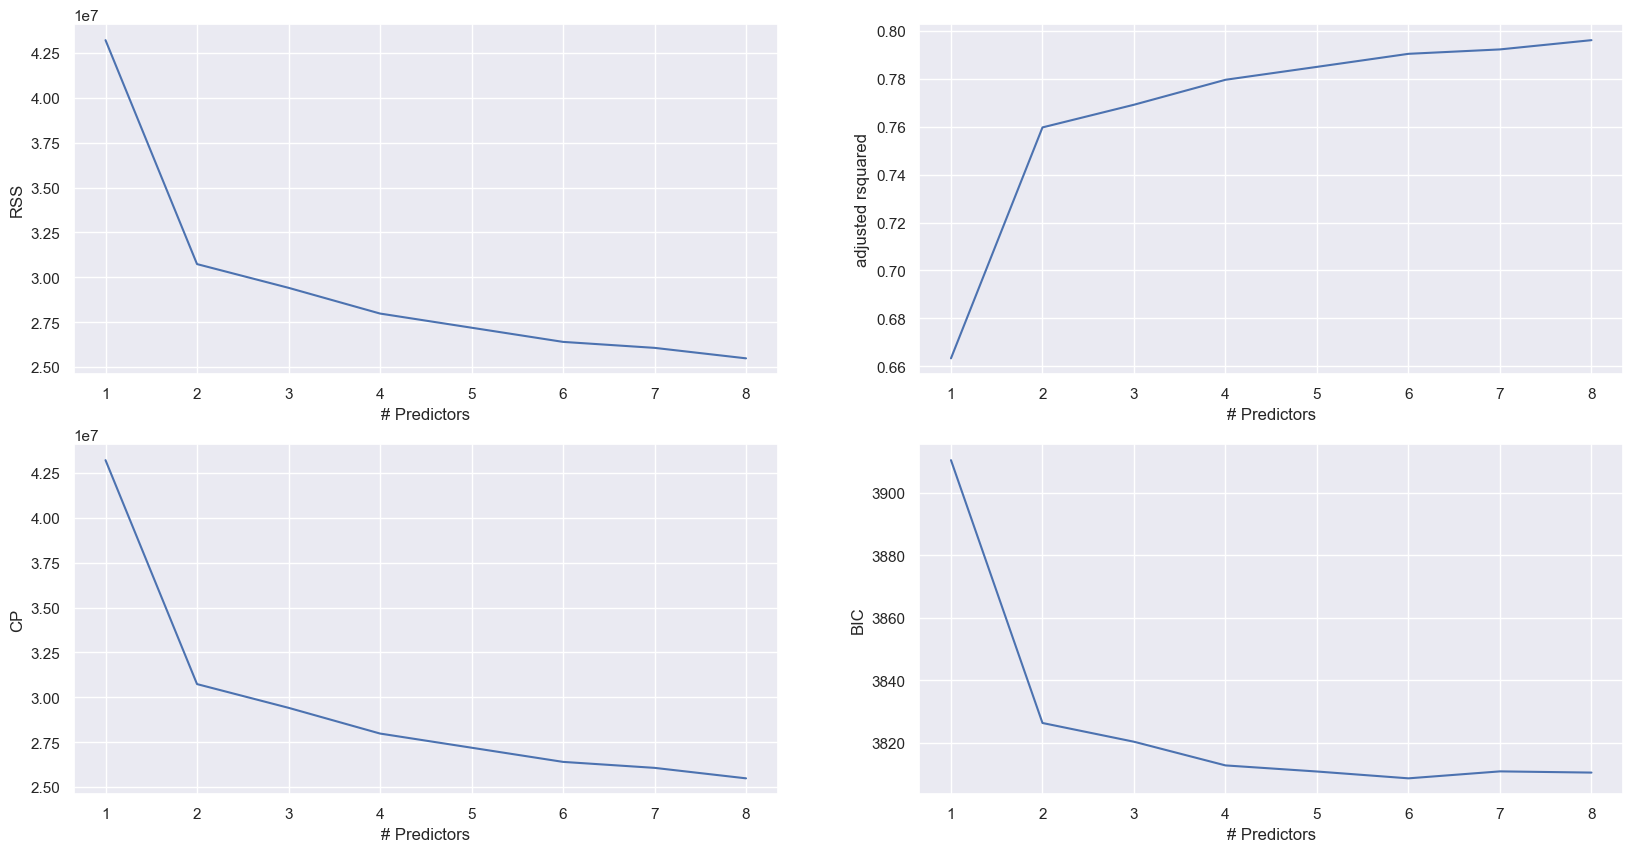

In [37]:
plt.figure(figsize=(20,10))
plt.rcParams.update({'font.size': 18, 'lines.markersize': 10})

# Set up a 2x2 grid so we can look at 4 plots at once
plt.subplot(2, 2, 1)

# We will now plot a red dot to indicate the model with the largest adjusted R^2 statistic.
# The argmax() function can be used to identify the location of the maximum point of a vector
plt.plot(models_best["RSS"])
plt.xlabel('# Predictors')
plt.ylabel('RSS')

# We will now plot a red dot to indicate the model with the largest adjusted R^2 statistic.
# The argmax() function can be used to identify the location of the maximum point of a vector

plt.subplot(2, 2, 2)
plt.plot(models_best["rsquared_adj"])
# plt.plot(models_best["rsquared_adj"].argmax(), models_best["rsquared_adj"].max(), "or")
plt.xlabel('# Predictors')
plt.ylabel('adjusted rsquared')

# We'll do the same for CP and BIC, this time looking for the models with the SMALLEST statistic

plt.subplot(2, 2, 3)
plt.plot(models_best["CP"])
# plt.plot(models_best["CP"].argmin(), models_best["CP"].min(), "or")
plt.xlabel('# Predictors')
plt.ylabel('CP')


plt.subplot(2, 2, 4)
plt.plot(models_best["BIC"])
# plt.plot(models_best["BIC"].argmin(), models_best["BIC"].min(), "or")
plt.xlabel('# Predictors')
plt.ylabel('BIC')

## Regularization

In [43]:
class Regularization:
    def __init__(self, X, y):
        scaler = StandardScaler()
        self.X = scaler.fit_transform(X)
        self.y = y
        self.n_features = X.shape[1]
        self.lasso = LassoCV(cv=10, random_state=42)
        self.ridge = RidgeCV(cv=10)
        self.alpha = 10**np.linspace(10, -2, 100)
        self.grid_ridge = Ridge(random_state=42)
        self.grid_lasso = Lasso(random_state=42)
        self.model = self.ridge.fit(self.X, self.y)
    
    def lasso_reg(self):
        self.lasso.fit(self.X,self.y)
        y_pred = self.lasso.predict(self.X)
        mse = mean_squared_error(self.y, y_pred)
        print("MSE (Lasso):", mse)
        print("Alpha (Lasso):", self.lasso.alpha_)
        print("Coefficients (Lasso):", self.lasso.coef_)
        
    def ridge_reg(self):
        self.ridge.fit(self.X,self.y)
        y_pred = self.ridge.predict(self.X)
        mse = mean_squared_error(self.y, y_pred)
        print("MSE (Ridge):", mse)
        print("Alpha (Ridge):", self.ridge.alpha_)
        print("Coefficients (Ridge):", self.ridge.coef_)
    
    def grid_search_ridge(self):
        coefs=[]
        intercept=[]
        for i in self.alpha:
            self.grid_ridge.set_params(alpha=i)
            self.grid_ridge.fit(self.X, self.y)
            coefs.append(self.grid_ridge.coef_)
            intercept.append(self.grid_ridge.intercept_)
        plt.figure(figsize = (16,8))
        ax = plt.gca()
        ax.plot(self.alpha, coefs)
        ax.set_xscale('log')
        plt.axis('tight')
        plt.xlabel('alpha')
        plt.ylabel('weights')
        plt.draw()

    def grid_search_lasso(self):
        coefs=[]
        intercept=[]
        for i in self.alpha:
            self.grid_lasso.set_params(alpha=i)
            self.grid_lasso.fit(self.X, self.y)
            coefs.append(self.grid_lasso.coef_)
            intercept.append(self.grid_lasso.intercept_)
        plt.figure(figsize = (16,8))
        ax = plt.gca()
        ax.plot(self.alpha, coefs)
        ax.set_xscale('log')
        plt.axis('tight')
        plt.xlabel('alpha')
        plt.ylabel('weights')
        plt.draw()
        
    def plot_alpha(self):
        self.ridge.fit(self.X,self.y)
        self.lasso.fit(self.X,self.y)
        plt.figure(figsize = (16,8))
        plt.plot(self.lasso.alphas_, self.lasso.mse_path_, ':')
        plt.plot(self.lasso.alphas_, self.lasso.mse_path_.mean(axis=-1), 'k',
                label=r'Average across the folds', linewidth=2)
        plt.axvline(self.lasso.alpha_, linestyle='--', color='k',
                    label='alpha: CV estimate')

        plt.legend()
        plt.xlabel(r'$\alpha$')
        plt.ylabel('Mean square error')
        plt.title('Mean square error on each fold: coordinate descent ')
        plt.axis('tight')
        plt.draw()
        
    def plot_coefficients(self):
        self.ridge.fit(self.X,self.y)
        self.lasso.fit(self.X,self.y)
        plt.figure(figsize = (16,8))
        plt.plot(self.lasso.coef_, 's', label='Lasso')
        plt.plot(self.ridge.coef_, 'o', label='Ridge')
        plt.xlabel("Features")
        plt.ylabel("Coefficients")
        plt.title("Coefficients vs Features")
        plt.legend(loc='best')
        plt.draw()

    def plot_alpha_MSE(self, model_name):
        if model_name == "lasso":
            model = self.lasso
            self.lasso.fit(self.X,self.y)
        else:
            model = self.ridge
            self.ridge.fit(self.X,self.y)
        MSE = np.mean(model.mse_path_, axis=1)
        plt.plot(model.alphas_, MSE, "k-")
        plt.xscale("log")
        plt.xlabel("Alpha")
        plt.ylabel("Mean Squared Error")
        plt.title("Mean Squared Error vs Alpha")
        plt.draw()

    def plot_alpha_coeffs(self, model_name):
        if model_name == "lasso":
            model = self.lasso
            self.lasso.fit(self.X,self.y)
        else:
            model = self.ridge
            self.ridge.fit(self.X,self.y)
        coeffs = model.coef_
        plt.plot(model.alphas_, coeffs, "k-")
        plt.xscale("log")
        plt.xlabel("Alpha")
        plt.ylabel("Coefficients")
        plt.title("Coefficients vs Alpha")
        plt.draw()


In this function, we start with all the features selected and iteratively remove one feature at a time while checking the mean squared error (MSE) of the model. The feature that results in the smallest MSE when removed is kept removed and this process continues until no further improvement in the MSE can be obtained.

Use the following code to call methods. Here, X and y are your input data and target variables respectively. You can call the different functions in the class to perform best subset selection, forward selection, backward selection and regularization. The class will store the best subset and its MSE, as well as the selected features from forward and backward selection. Additionally, the Lasso and Ridge regularization will give the best alpha and MSE for the regularization.

In [44]:
# create an instance of the class with your X and y data
reg = Regularization(X, y)

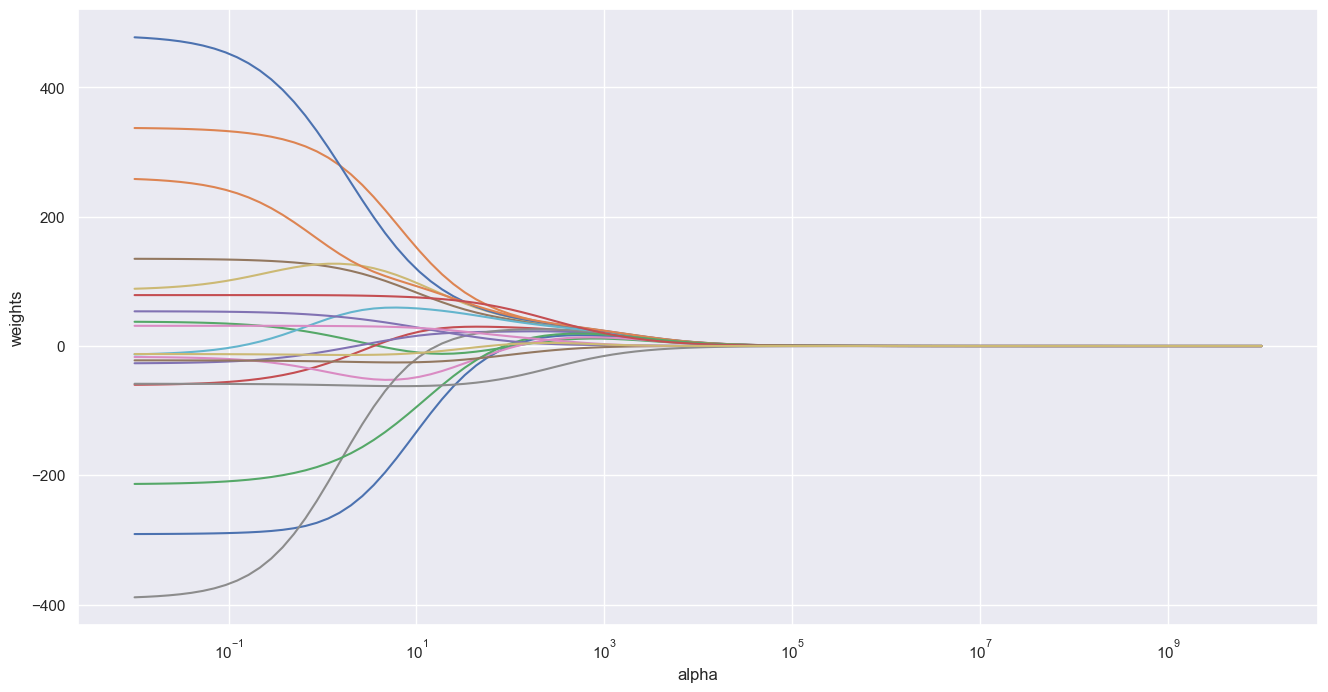

In [45]:

# call the function for grid search using ridge regularization
reg.grid_search_ridge()

/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.099e+04, tolerance: 5.332e+03
  model = cd_fast.enet_coordinate_descent(
/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.760e+04, tolerance: 5.332e+03
  model = cd_fast.enet_coordinate_descent(
/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the featu

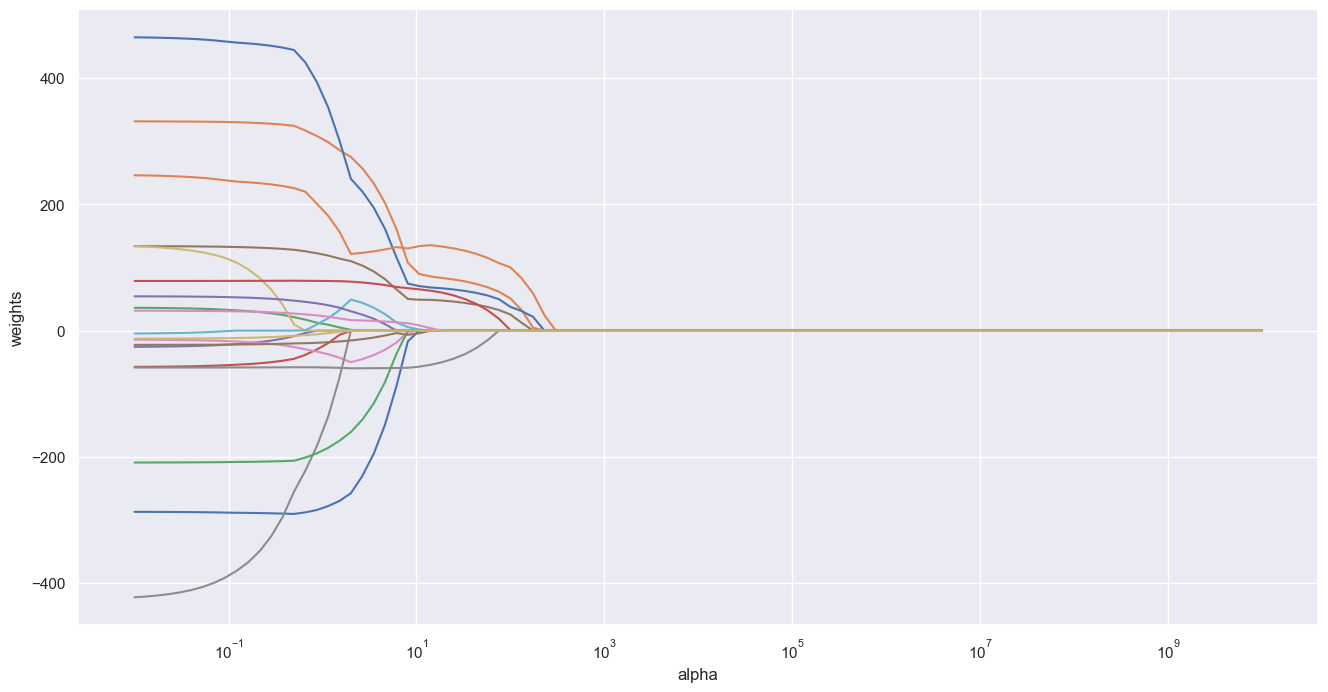

In [46]:

# call the function for grid search lasso regularization
reg.grid_search_lasso()

In [47]:
# call the function for CV=10 lasso regularization
reg.ridge_reg()

MSE (Ridge): 96656.8440316822
Alpha (Ridge): 10.0
Coefficients (Ridge): [-133.04956743  152.45702035   -9.81282039   21.18501935   15.68958721
   82.73983161  -48.55000891  -19.78800699   97.79093415   58.2602058
  119.29217452   92.64910677  -94.45127728   75.22794403   28.87460361
  -25.11029176   28.10955887  -61.96539877  -10.97188835]


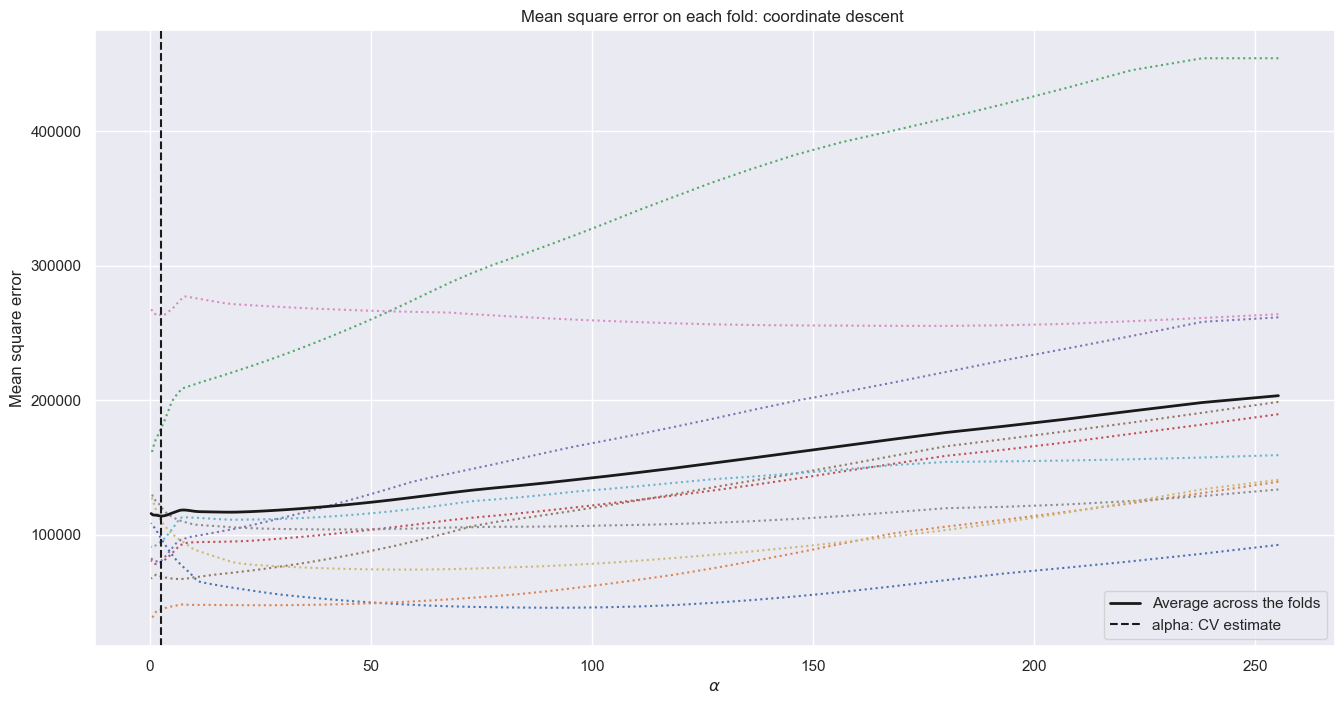

In [48]:
# plot alpha
reg.plot_alpha()

## Dimensional Reduction

In [49]:
class DimensionReduction:
    def __init__(self, X, y, n_components=None):
        self.X = X
        self.y = y
        self.n_components = n_components
        self.pcr = PCA(n_components=self.n_components)
        self.pls = PLSRegression(n_components=self.n_components)
        
    def fit_pcr(self, n_components=None):
        self.pcr = PCA(n_components=n_components)
        self.pcr.fit(self.X, self.y)
        
    def fit_pls(self, n_components=None):
        self.pls = PLSRegression(n_components=n_components)
        self.pls.fit(self.X, self.y)
        
    def find_best_n_components(self, method):
        if method == "pcr":
            model = self.pcr
        elif method == "pls":
            model = self.pls
        else:
            raise ValueError("method must be either 'pcr' or 'pls'")
        
        cv_scores = []
        for n in range(1, self.X.shape[1]+1):
            model.n_components = n
            score = np.mean(cross_val_score(model, self.X, self.y, cv =10))
            cv_scores.append(score)

        best_n_components = np.argmax(cv_scores) + 1
        print("Best number of components:", best_n_components)

        pcr_comps = np.arange(1, self.X.shape[1] + 1)
        plt.figure(figsize = (10,6)).gca()
        plt.plot(pcr_comps,cv_scores,marker = 'o', label= "PCR")
        plt.xlabel('Number of components')
        plt.ylabel('Cross-validated score')
        plt.title('Cross-validated score vs number of components')
        plt.xticks = [pcr_comps]
        plt.legend()
        plt.show()
        return best_n_components, cv_scores
    
    def plot_variability_captured(self, method):
        if method == "pcr":
            model = self.pcr
        elif method == "pls":
            model = self.pls
        else:
            raise ValueError("method must be either 'pcr' or 'pls'")
            
        explained_variance = model.explained_variance_ratio_
        cumulative_explained_variance = np.cumsum(explained_variance)
        plt.plot(np.arange(1, len(explained_variance)+1), cumulative_explained_variance)
        plt.xlabel("Number of components")
        plt.ylabel("Explained Variance")
        plt.show() 
        print(f"{np.array2string(cumulative_explained_variance, formatter={'float': lambda x: f'{x:.2f}'})}")
        return


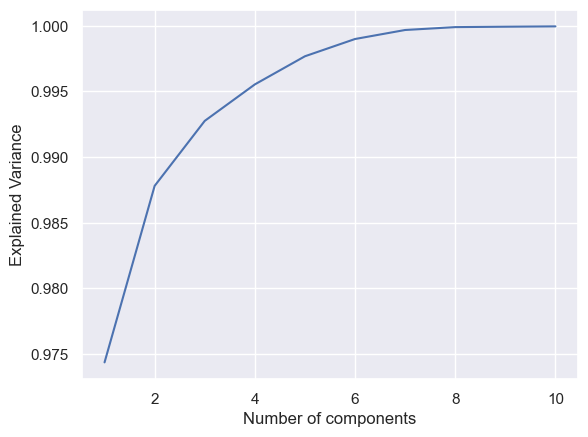

[0.97 0.99 0.99 1.00 1.00 1.00 1.00 1.00 1.00 1.00]


In [50]:
pcr_pls = DimensionReduction(X, y) #initialize an instance of the class
pcr_pls.fit_pcr(10) #fit a PCR model with 10 components
pcr_pls.fit_pls(10) #fit a PLS model with 10 components
pcr_pls.plot_variability_captured("pcr") #plot the variability captured by the components for both models
